In [25]:
import geopandas as gpd
import matplotlib.pyplot as plt
from cartopy import crs as ccrs
from geodatasets import get_path
import pandas as pd
from datetime import datetime, timedelta

In [ ]:
#Date function for title -> returns a string that states the start date - end date. 
#The start date is defined through the input variable (xdays_in_the_past) which is the number of days that will be subtracted from today's date.
#Example: xdays_in_the_past=10 and today's date is the 15.05.2026 -> output: 5. May 2026 - 15. May 2026

def datefunction(xdays_in_the_past):
    start_date = ((todays_date - timedelta(days=xdays_in_the_past)).date()).strftime("%d. %B %Y")
    end_date = (todays_date.date()).strftime("%d. %B %Y")
    date_span = (f"{start_date} - {end_date}")
    
    return date_span

26. April 2026 - 06. May 2026


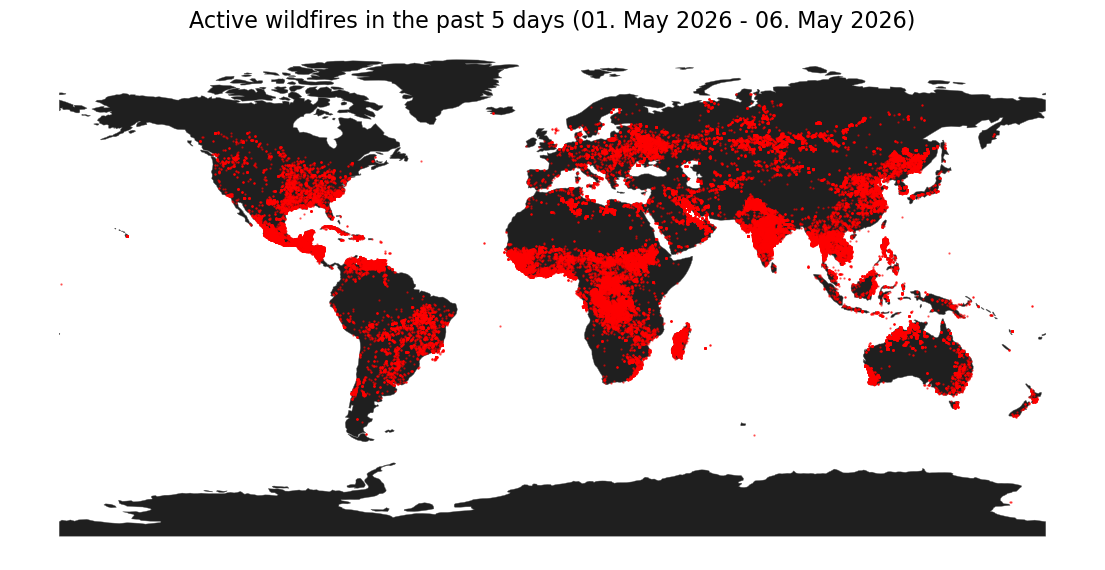

In [87]:
# Load world basemap from "geodatasets"
path = get_path("naturalearth.land")
world = gpd.read_file(path)

# FIRMS API: letzte 7 Tage VIIRS S-NPP
API_KEY = "875c5f8321acb83297f0d59448343c67"

url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{API_KEY}/VIIRS_SNPP_NRT/world/5"

firms_df = pd.read_csv(url)

# Convert fire data to georeferenced points
fires = gpd.GeoDataFrame(
    firms_df,
    geometry=gpd.points_from_xy(firms_df["longitude"], firms_df["latitude"]),
    crs="EPSG:4326"
)

# Worldmap
fig, ax = plt.subplots(figsize=(14, 7))

world.plot(
    ax=ax,
    color="#1f1f1f",
    edgecolor="#555555",
    linewidth=0.3
    
)

fires.plot(
    ax=ax,
    color="red",
    markersize=0.4,
    alpha=0.6
)

# Map cosmetics
ax.set_title(f"Active wildfires in the past 5 days ({datefunction(5)})", fontsize=16)
ax.set_axis_off()


plt.show()
